In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [65]:
df=pd.read_csv('diabetes_data.csv')

In [66]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,0.0,NaN,0.351,31.0,0.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0


In [67]:
df.shape

(768, 9)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               728 non-null    float64
 1   Glucose                   722 non-null    float64
 2   BloodPressure             735 non-null    float64
 3   SkinThickness             726 non-null    float64
 4   Insulin                   735 non-null    float64
 5   BMI                       729 non-null    float64
 6   DiabetesPedigreeFunction  734 non-null    float64
 7   Age                       735 non-null    float64
 8   Outcome                   739 non-null    float64
dtypes: float64(9)
memory usage: 54.1 KB


In [69]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,728.000000,722.000000,735.000000,726.000000,735.000000,729.000000,734.000000,735.000000,739.000000
mean,3.912088,120.671745,68.927891,20.632231,80.268027,32.028807,0.467578,33.308844,0.341001
std,3.382204,31.982858,19.590744,16.012616,116.198612,7.904681,0.325979,11.727195,0.474367
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.238250,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,29.000000,32.000000,0.368000,29.000000,0.000000
75%,6.000000,140.750000,80.000000,32.000000,130.000000,36.600000,0.622750,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [70]:
# Null Values in Each Column
df.isnull().sum()

,0
Pregnancies,40
Glucose,46
BloodPressure,33
SkinThickness,42
Insulin,33
BMI,39
DiabetesPedigreeFunction,34
Age,33
Outcome,29


In [71]:
# Outlier Detection
q1=df['Pregnancies'].quantile(0.25)
q3=df['Pregnancies'].quantile(0.75)
IQR=q3-q1
lowerlimit=q1-1.5*IQR
upperlimit=q3+1.5*IQR

In [72]:
df[(df['Pregnancies']<lowerlimit) | (df['Pregnancies']>upperlimit)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
88,15.0,NaN,70.0,32.0,110.0,37.1,0.153,43.0,1.0
159,17.0,163.0,72.0,41.0,114.0,40.9,0.817,47.0,1.0
298,14.0,100.0,78.0,25.0,184.0,36.6,0.412,46.0,1.0
455,14.0,175.0,62.0,30.0,0.0,33.6,0.212,38.0,1.0


In [73]:
df['Pregnancies']=df['Pregnancies'].fillna(df['Pregnancies'].median())
# replaced the NULL Values with the Median ...why median is there is some outliers

In [74]:
df['Pregnancies'].value_counts()
# The aim is to check how many 0 pregenices..we didn't replace them because they are valid

,count
Pregnancies,
1.0,124
3.0,111
0.0,101
2.0,100
4.0,66
5.0,54
6.0,47
7.0,43
8.0,37


In [75]:
# Outlier Detection
q1=df['Glucose'].quantile(0.25)
q3=df['Glucose'].quantile(0.75)
IQR=q3-q1
lowerlimit=q1-1.5*IQR
upperlimit=q3+1.5*IQR


In [76]:
df[(df['Glucose']<lowerlimit) | (df['Glucose']>upperlimit)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1.0,0.0,48.0,20.0,0.0,24.7,0.140,22.0,0.0
182,1.0,0.0,74.0,20.0,23.0,27.7,0.299,21.0,0.0
342,1.0,0.0,68.0,35.0,0.0,32.0,0.389,22.0,0.0
349,5.0,0.0,80.0,32.0,0.0,41.0,0.346,37.0,1.0
502,6.0,0.0,68.0,41.0,0.0,39.0,0.727,41.0,1.0


In [77]:

df['Glucose']=df['Glucose'].replace(0.0,np.nan)

In [78]:
df['Glucose']=df['Glucose'].fillna(df['Glucose'].median())

In [79]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,0.0,NaN,0.351,31.0,0.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0,0.0
764,3.0,122.0,70.0,27.0,0.0,36.8,0.340,27.0,0.0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0.0
766,1.0,126.0,60.0,0.0,0.0,30.1,0.349,47.0,1.0


In [80]:
# Outlier Detection
q1=df['BloodPressure'].quantile(0.25)
q3=df['BloodPressure'].quantile(0.75)
IQR=q3-q1
lowerlimit=q1-1.5*IQR
upperlimit=q3+1.5*IQR


In [81]:
print(lowerlimit)
print(upperlimit)

35.0
107.0


In [82]:
df[(df['BloodPressure']<lowerlimit) | (df['BloodPressure']>upperlimit)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10.0,115.0,0.0,0.0,0.0,35.3,0.134,NaN,0.0
15,7.0,100.0,0.0,0.0,NaN,30.0,0.484,32.0,1.0
18,1.0,103.0,30.0,38.0,83.0,43.3,0.183,33.0,0.0
43,9.0,171.0,110.0,24.0,240.0,45.4,0.721,54.0,1.0
49,7.0,105.0,0.0,0.0,0.0,0.0,0.305,24.0,0.0
60,2.0,84.0,0.0,0.0,0.0,0.0,0.304,21.0,0.0
78,0.0,131.0,0.0,0.0,0.0,43.2,0.270,26.0,1.0
81,2.0,74.0,0.0,0.0,0.0,0.0,0.102,22.0,0.0
84,5.0,137.0,108.0,0.0,0.0,48.8,0.227,37.0,1.0
106,1.0,117.0,122.0,0.0,0.0,22.4,0.207,27.0,0.0


In [83]:
cols = [ 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

In [84]:
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_1301/1610507378.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1301/1610507378.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [85]:
df['Outcome'].isnull().sum()

np.int64(29)

In [86]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,127.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,127.0,32.2,0.351,31.0,0.0
2,8.0,183.0,64.0,29.0,127.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0,0.0
764,3.0,122.0,70.0,27.0,127.0,36.8,0.340,27.0,0.0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0.0
766,1.0,126.0,60.0,29.0,127.0,30.1,0.349,47.0,1.0


In [87]:
df['DiabetesPedigreeFunction'].fillna(
    df['DiabetesPedigreeFunction'].median(),
    inplace=True
)

/tmp/ipykernel_1301/2160765010.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DiabetesPedigreeFunction'].fillna(


In [88]:
df['Outcome'].fillna(df['Outcome'].mode()[0], inplace=True)

/tmp/ipykernel_1301/1878893707.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Outcome'].fillna(df['Outcome'].mode()[0], inplace=True)


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    float64
dtypes: float64(9)
memory usage: 54.1 KB


In [90]:
int_cols = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'Age',
    'Outcome'
]

df[int_cols] = df[int_cols].astype('int64')


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


- After imputing the missing values, I converted the columns that represent whole numbers to int64. I kept BMI and DiabetesPedigreeFunction as float64 because they naturally contain decimal values. This ensures each feature has the correct data type for analysis and machine learning.

In [92]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,127,33.6,0.627,50,1
1,1,85,66,29,127,32.2,0.351,31,0
2,8,183,64,29,127,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,3,122,70,27,127,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,29,127,30.1,0.349,47,1


In [93]:
df.to_csv('cleaned_dataset.csv')

In [96]:
df=pd.read_csv('diabetes_data.csv')


In [94]:
df1=pd.read_csv('cleaned_dataset.csv')

In [97]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,0.0,NaN,0.351,31.0,0.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0


In [98]:
df1.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148,72,35,127,33.6,0.627,50,1
1,1,1,85,66,29,127,32.2,0.351,31,0
2,2,8,183,64,29,127,23.3,0.672,32,1
3,3,1,89,66,23,94,28.1,0.167,21,0
4,4,0,137,40,35,168,43.1,2.288,33,1


In [99]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             768 non-null    int64  
 4   SkinThickness             768 non-null    int64  
 5   Insulin                   768 non-null    int64  
 6   BMI                       768 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
 9   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 60.1 KB


## Visualizations


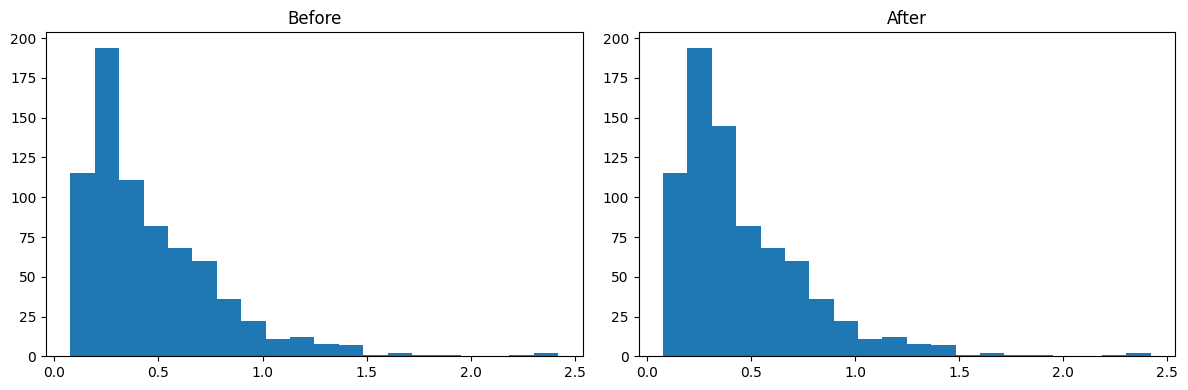

In [103]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].hist(df['DiabetesPedigreeFunction'], bins=20)
ax[0].set_title("Before")

ax[1].hist(df1['DiabetesPedigreeFunction'], bins=20)
ax[1].set_title("After")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'After')

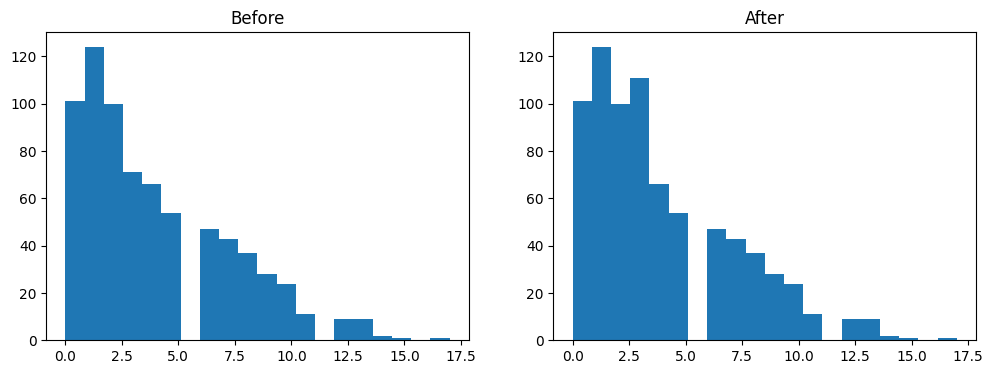

In [106]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].hist(df['Pregnancies'], bins=20)
ax[0].set_title("Before")

ax[1].hist(df1['Pregnancies'], bins=20)
ax[1].set_title("After")

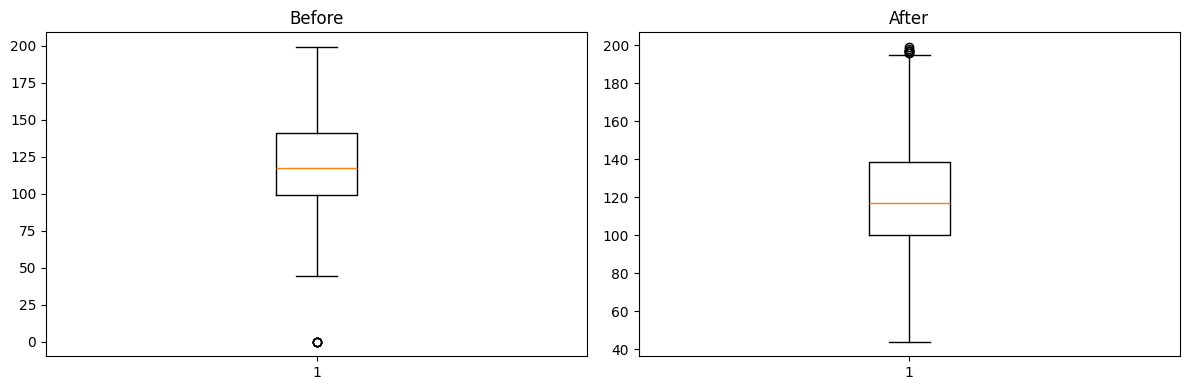

In [111]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].boxplot(df['Glucose'].dropna())
ax[0].set_title("Before")

ax[1].boxplot(df1['Glucose'])
ax[1].set_title("After")
plt.tight_layout()
plt.show()

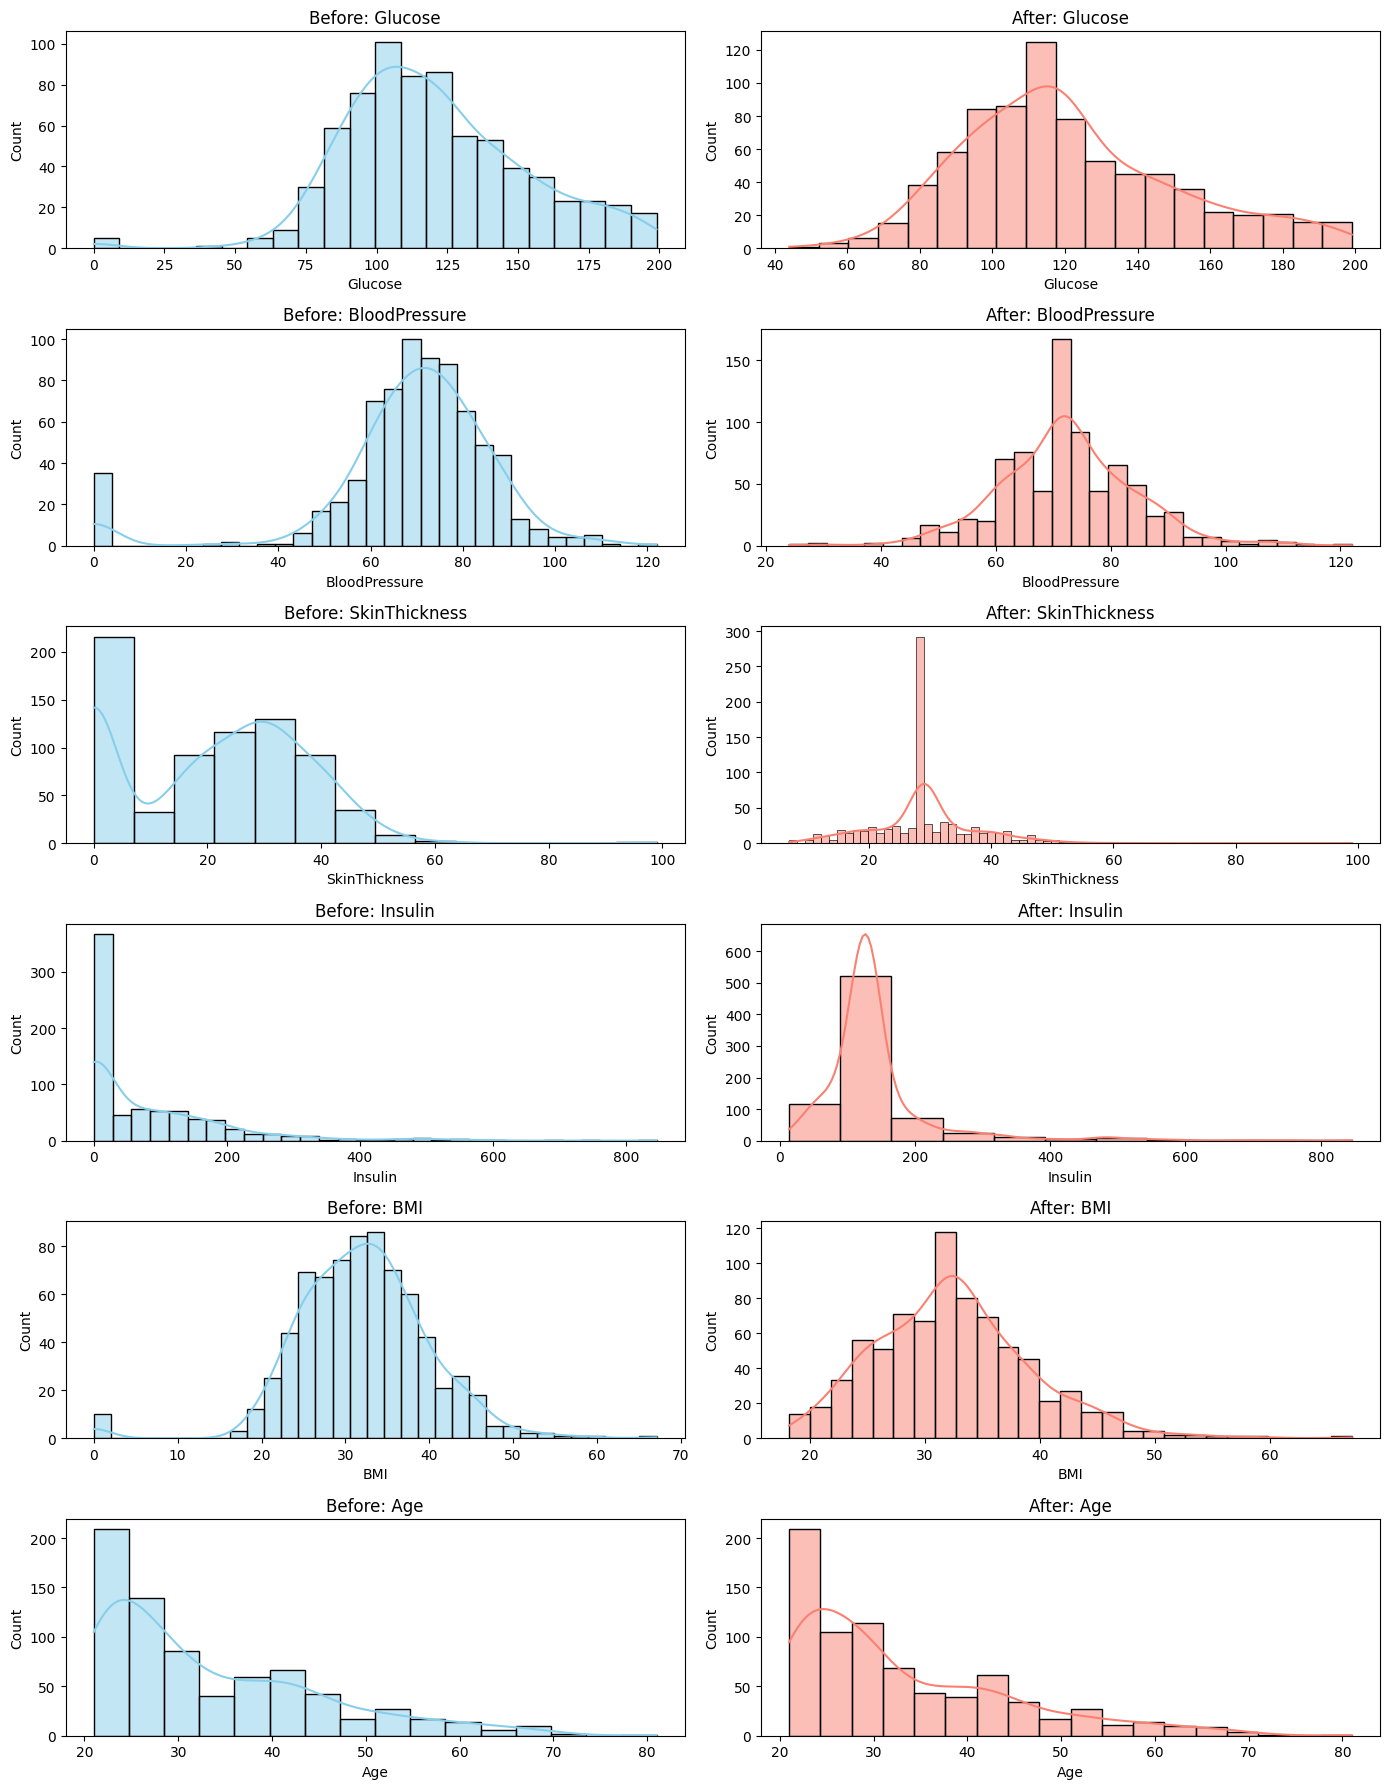

In [112]:
features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']
fig, axes = plt.subplots(len(features), 2, figsize=(14, 18))

for i, col in enumerate(features):
    # Before cleaning
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Before: {col}')

    # After cleaning
    sns.histplot(df1[col], kde=True, ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'After: {col}')

plt.tight_layout()
plt.show()

1. Glucose (Median Imputation)

Observations:

> Before imputation, the distribution contained invalid zero values that created an artificial peak near 0.
After replacing missing values with the median, the distribution became smoother and more centered around the typical glucose levels.
The overall shape of the distribution remained similar, indicating that median imputation did not distort the data.
Median was an appropriate choice because glucose values are slightly skewed and may contain outliers.


2. BloodPressure (Median Imputation)

Observations:

> The original distribution showed several impossible zero blood pressure values.
After median imputation, the spike at zero disappeared and the distribution became more realistic.
Outliers were preserved while the missing-value issue was resolved.
Median imputation was appropriate because blood pressure measurements may contain skewness and outliers.

*3. SkinThickness (Median Imputation)*

Observations:

> Before imputation, many zero values caused an unrealistic spike at the beginning of the distribution.
After replacing missing values with the median, the spike shifted to the median value, creating a noticeable peak around the center.
The overall distribution became more realistic, although the median value appears more frequently due to imputation.
Median was suitable because SkinThickness is highly skewed and contains many missing values.

*4. Insulin (Median Imputation)*

Observations:

> The original distribution had a large number of zero values, producing a strong spike at the lower end.
After imputation, the spike at zero disappeared and missing values were concentrated around the median.
The distribution remained right-skewed, which reflects the natural characteristics of insulin measurements.
Median imputation was appropriate because insulin contains extreme outliers and is highly skewed.

*5. BMI (Median Imputation)*

Observations:

> Before imputation, invalid zero BMI values affected the distribution.
After median imputation, the zero values disappeared and the histogram became smoother.
The overall distribution remained close to its original shape without being influenced by outliers.
Median was the correct choice because BMI can be skewed and contains extreme values.

*6. Age (Median Imputation)*

Observations:

> Only a few age values were missing, so the distribution changed very little after imputation.
The overall right-skewed pattern remained unchanged.
No new outliers were introduced, and the data quality improved by removing missing values.
Median imputation was appropriate because it preserves the central tendency without being affected by outliers.

Select Numerical Features

In [120]:
# Exclude target column
X = df1.drop('Outcome', axis=1)

Apply StandardScaler

In [121]:
standard_scaler = StandardScaler()

standard_scaled_df = pd.DataFrame(
    standard_scaler.fit_transform(X),
    columns=X.columns
)

standard_scaled_df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-1.729797,0.647700,0.910187,-0.028887,0.678262,-0.172073,0.169129,0.513379,1.467770
1,-1.725286,-0.868866,-1.230513,-0.536938,-0.019846,-0.172073,-0.037987,-0.351493,-0.184703
2,-1.720776,1.254327,2.099465,-0.706288,-0.019846,-0.172073,-1.354650,0.654391,-0.097731
3,-1.716265,-0.868866,-1.094596,-0.536938,-0.717955,-0.559891,-0.644539,-0.928075,-1.054425
4,-1.711755,-1.172180,0.536414,-2.738493,0.678262,0.309762,1.574556,5.718284,-0.010758


Apply MinMaxScaler

In [140]:
minmax_scaler = MinMaxScaler()

minmax_scaled_df = pd.DataFrame(
    minmax_scaler.fit_transform(X),
    columns=X.columns
)

minmax_scaled_df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.000000,0.352941,0.670968,0.489796,0.304348,0.135817,0.314928,0.234415,0.483333
1,0.001304,0.058824,0.264516,0.428571,0.239130,0.135817,0.286299,0.116567,0.166667
2,0.002608,0.470588,0.896774,0.408163,0.239130,0.135817,0.104294,0.253629,0.183333
3,0.003911,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000
4,0.005215,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000


RobustScaler

In [127]:
robust_scaler = RobustScaler()

robust_scaled_df = pd.DataFrame(
    robust_scaler.fit_transform(X),
    columns=X.columns
)

robust_scaled_df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-1.000000,0.6,0.810458,0.000000,1.0,0.0,0.162791,0.719444,1.3125
1,-0.997392,-0.4,-0.836601,-0.400000,0.0,0.0,0.000000,-0.047222,0.1250
2,-0.994785,1.0,1.725490,-0.533333,0.0,0.0,-1.034884,0.844444,0.1875
3,-0.992177,-0.4,-0.732026,-0.400000,-1.0,-33.0,-0.476744,-0.558333,-0.5000
4,-0.989570,-0.6,0.522876,-2.133333,1.0,41.0,1.267442,5.333333,0.2500


In [125]:
standard_scaled_df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-1.729797,0.647700,0.910187,-0.028887,0.678262,-0.172073,0.169129,0.513379,1.467770
1,-1.725286,-0.868866,-1.230513,-0.536938,-0.019846,-0.172073,-0.037987,-0.351493,-0.184703
2,-1.720776,1.254327,2.099465,-0.706288,-0.019846,-0.172073,-1.354650,0.654391,-0.097731
3,-1.716265,-0.868866,-1.094596,-0.536938,-0.717955,-0.559891,-0.644539,-0.928075,-1.054425
4,-1.711755,-1.172180,0.536414,-2.738493,0.678262,0.309762,1.574556,5.718284,-0.010758


In [124]:
minmax_scaled_df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.000000,0.352941,0.670968,0.489796,0.304348,0.135817,0.314928,0.234415,0.483333
1,0.001304,0.058824,0.264516,0.428571,0.239130,0.135817,0.286299,0.116567,0.166667
2,0.002608,0.470588,0.896774,0.408163,0.239130,0.135817,0.104294,0.253629,0.183333
3,0.003911,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000
4,0.005215,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000


In [128]:
robust_scaled_df.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-1.000000,0.6,0.810458,0.000000,1.0,0.0,0.162791,0.719444,1.3125
1,-0.997392,-0.4,-0.836601,-0.400000,0.0,0.0,0.000000,-0.047222,0.1250
2,-0.994785,1.0,1.725490,-0.533333,0.0,0.0,-1.034884,0.844444,0.1875
3,-0.992177,-0.4,-0.732026,-0.400000,-1.0,-33.0,-0.476744,-0.558333,-0.5000
4,-0.989570,-0.6,0.522876,-2.133333,1.0,41.0,1.267442,5.333333,0.2500


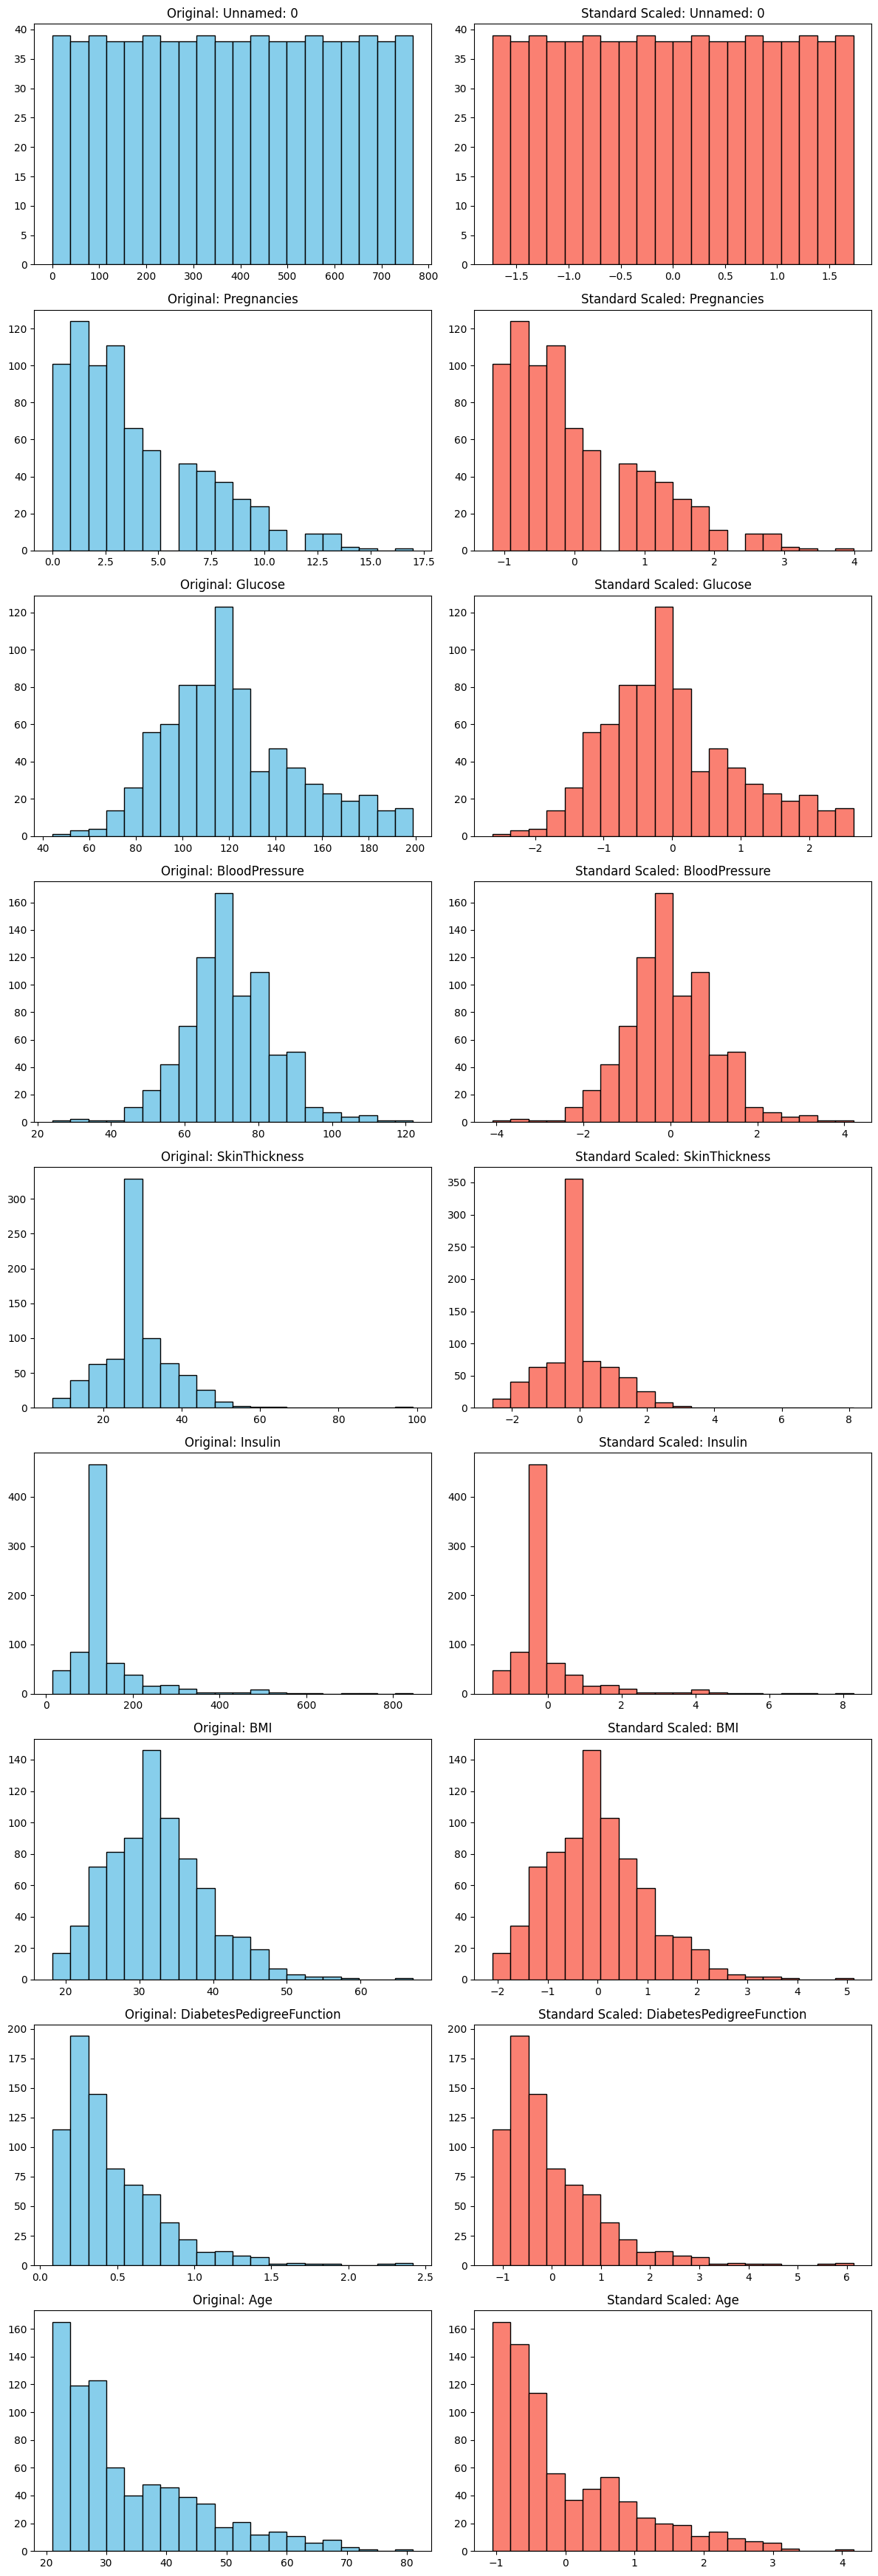

In [129]:
features = X.columns

fig, axes = plt.subplots(len(features), 2, figsize=(12, 35))

for i, col in enumerate(features):
    # Original
    axes[i,0].hist(X[col], bins=20, color='skyblue', edgecolor='black')
    axes[i,0].set_title(f'Original: {col}')

    # Standard Scaled
    axes[i,1].hist(standard_scaled_df[col], bins=20, color='salmon', edgecolor='black')
    axes[i,1].set_title(f'Standard Scaled: {col}')

plt.tight_layout()
plt.show()

In [134]:
minmax_scaled_df.drop(columns='Unnamed: 0',inplace=True)

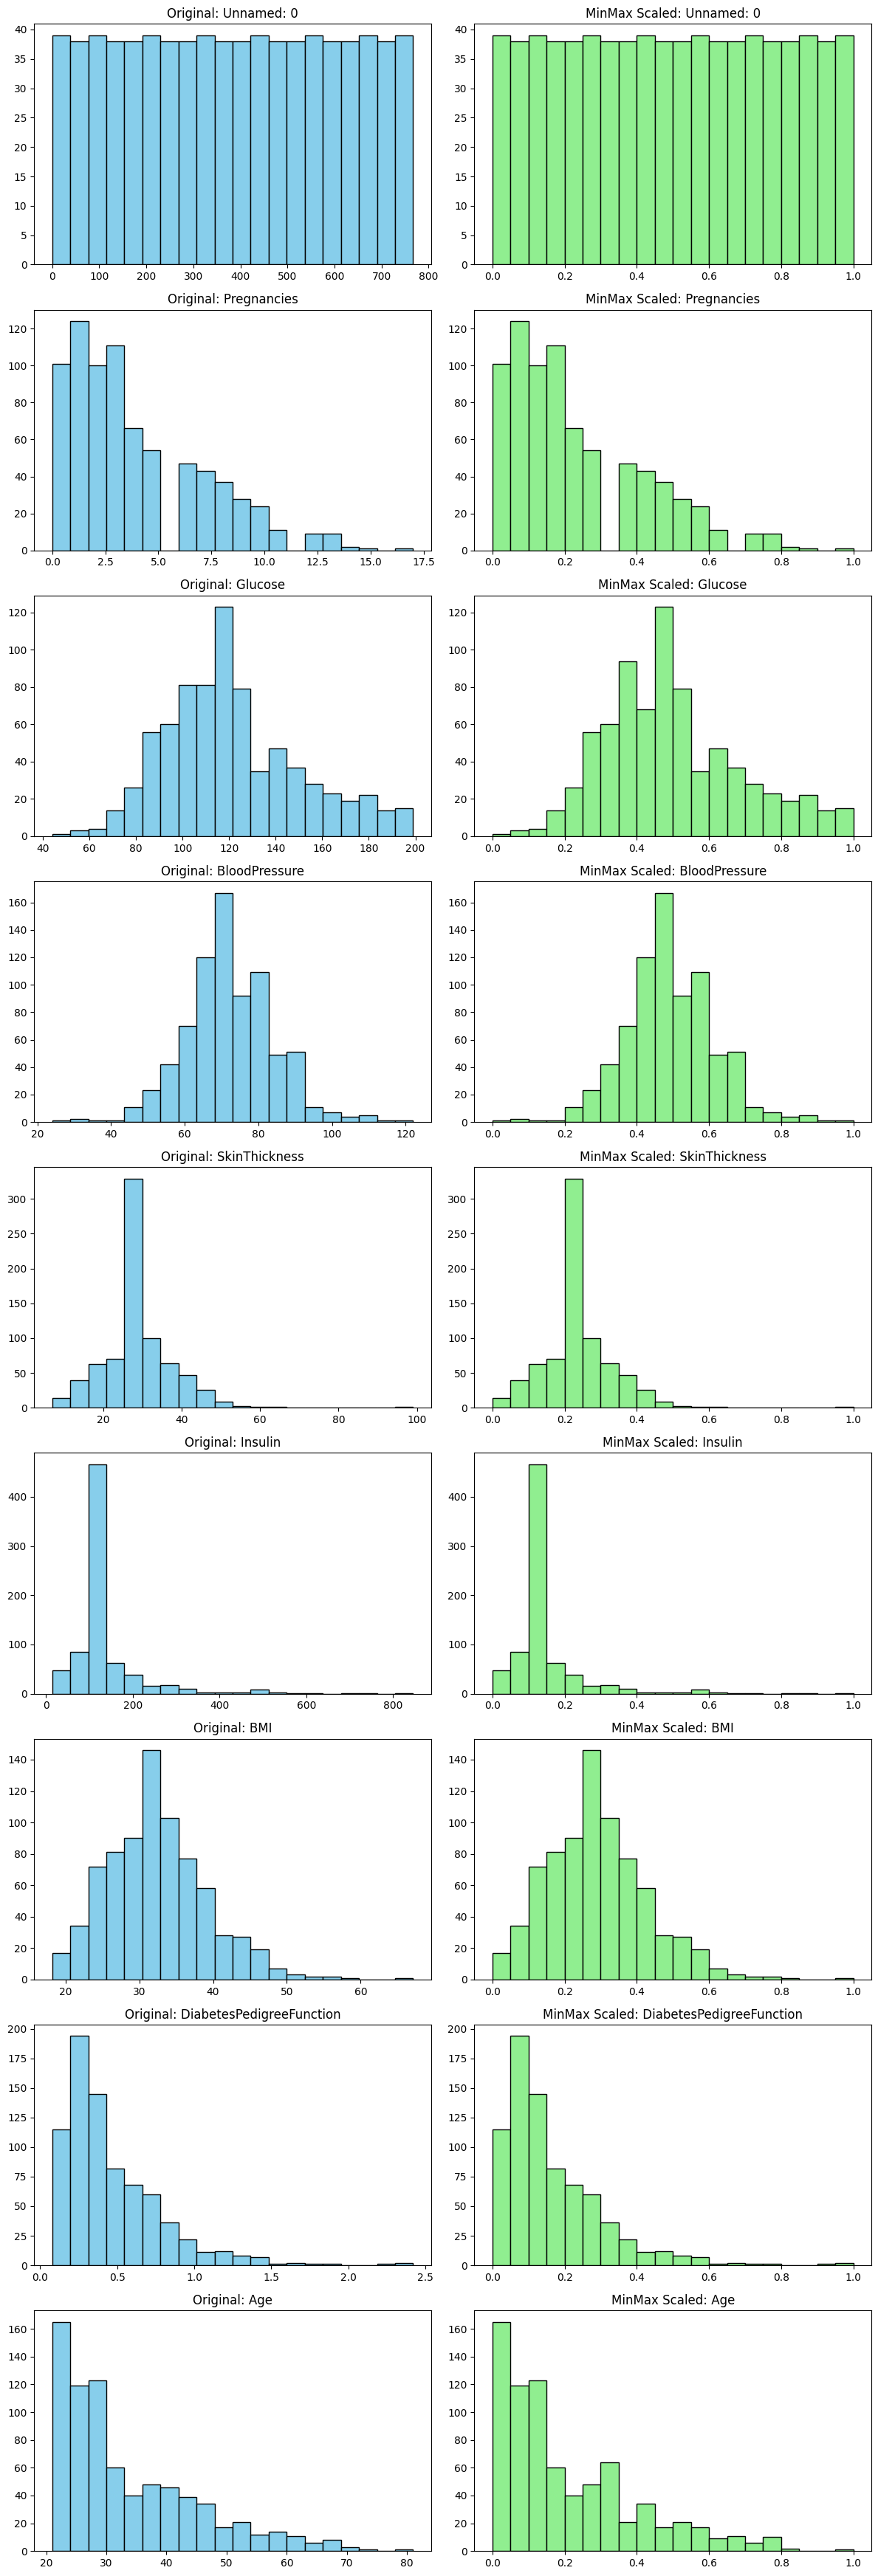

In [141]:
fig, axes = plt.subplots(len(features), 2, figsize=(12, 35))

for i, col in enumerate(features):

    axes[i,0].hist(X[col], bins=20, color='skyblue', edgecolor='black')
    axes[i,0].set_title(f'Original: {col}')

    axes[i,1].hist(minmax_scaled_df[col], bins=20, color='lightgreen', edgecolor='black')
    axes[i,1].set_title(f'MinMax Scaled: {col}')

plt.tight_layout()
plt.show()

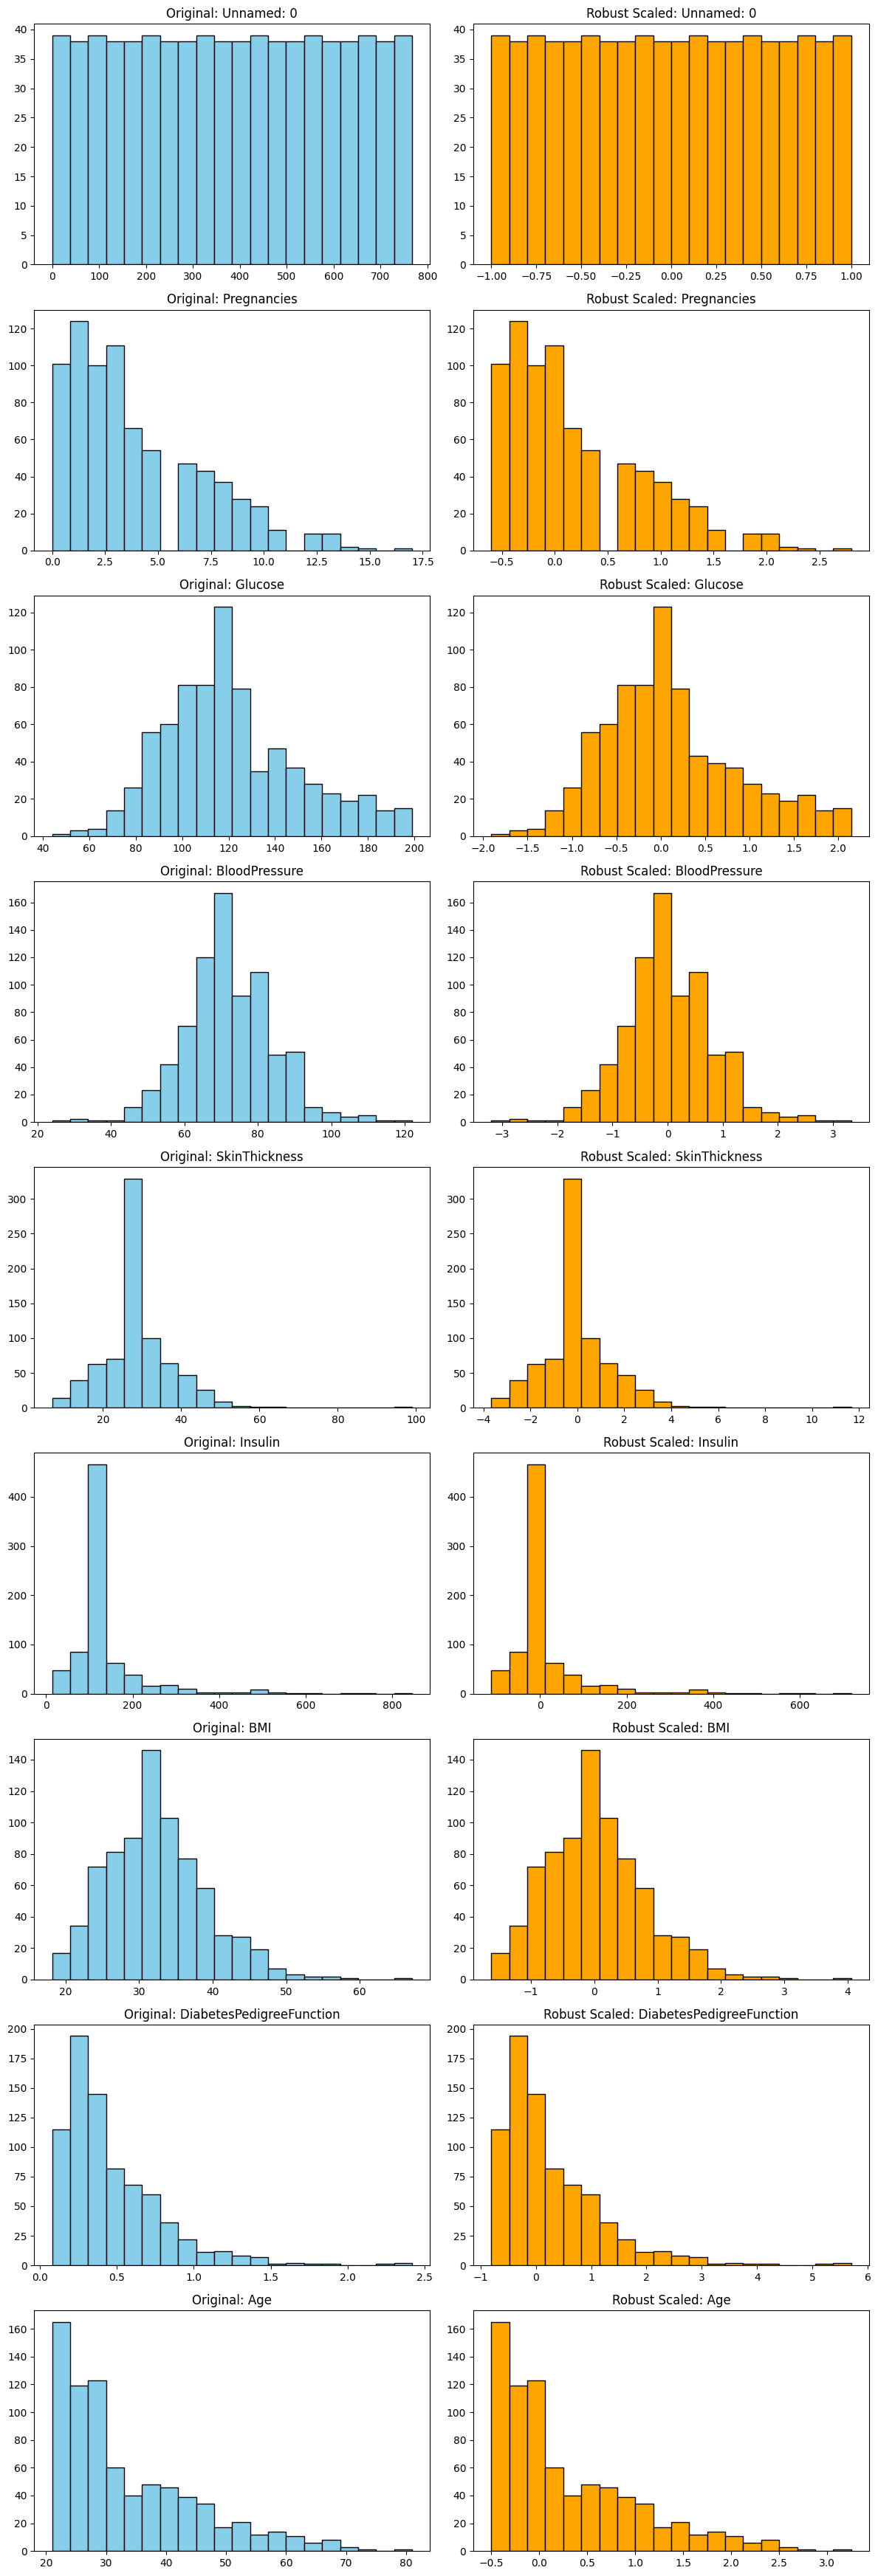

In [142]:
fig, axes = plt.subplots(len(features), 2, figsize=(12, 35))

for i, col in enumerate(features):

    axes[i,0].hist(X[col], bins=20, color='skyblue', edgecolor='black')
    axes[i,0].set_title(f'Original: {col}')

    axes[i,1].hist(robust_scaled_df[col], bins=20, color='orange', edgecolor='black')
    axes[i,1].set_title(f'Robust Scaled: {col}')

plt.tight_layout()
plt.show()

*Observations for StandardScaler*

> StandardScaler transformed each feature to have approximately mean = 0 and standard deviation = 1.

> The overall shape of each distribution remained the same because scaling changes the values, not the distribution.

*Observations for MinMaxScaler*

> MinMaxScaler rescaled all feature values into the range 0 to 1.
> The relative ordering and shape of the data remained unchanged.

*Observations for RobustScaler*

> RobustScaler centered the data using the median and scaled it using the Interquartile Range (IQR).
> It reduced the influence of extreme outliers while preserving the overall distribution.
Most values became concentrated around the center, making skewed features easier to analyze

In [144]:
# Save Standard Scaled Data
standard_scaled_df.to_csv("diabetes_standard_scaled.csv", index=False)

# Save MinMax Scaled Data
minmax_scaled_df.to_csv("diabetes_minmax_scaled.csv", index=False)

# Save Robust Scaled Data
robust_scaled_df.to_csv("diabetes_robust_scaled.csv", index=False)

